In [12]:
#Linear regression using scikit learns library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('placement.csv')

df.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'PACKAGE(in LPA)')

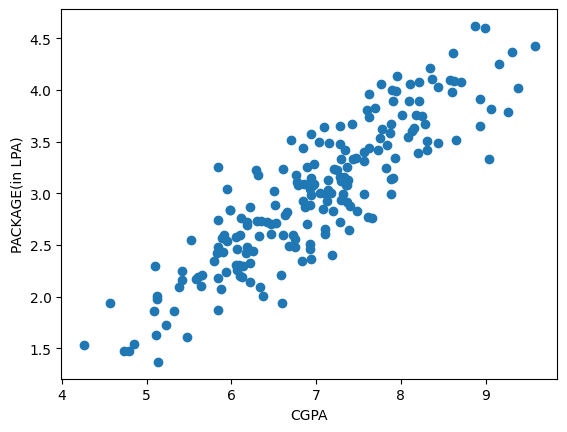

In [17]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('PACKAGE(in LPA)')

In [43]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]



0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [14]:
# iloc[rows, columns]
#       ↓       ↓
#       :       0:1 - defining like this makes the array 2D which is only allowed,the same does not apply for y because its supposed to be 1D
#    all rows   columns from 0 up to 1 (excluding 1)
#               → only column 0 

# -1 means LAST column

# y = df.iloc[:, -1] → picks package (last column)

In [15]:
from sklearn.model_selection import train_test_split as tts
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.2,random_state=2)

In [32]:
from sklearn.linear_model import LinearRegression 
lr=LinearRegression()
lr.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [29]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [25]:
lr.predict(X_test.iloc[0].values.reshape(1,1))


# Suppose the dataset X_test is -

# X_test = | 6.5 |
#          | 7.2 |
#          | 8.1 |
#          | 5.9 |

# X_test.iloc[0] — grab FIRST row only:
# → 6.5    ← just one value

# .values — convert from pandas Series to numpy array:
# pandas Series: 6.5  ← has index, labels etc
# numpy array:  [6.5] ← just raw number, no extra info

# .reshape(1,1) — reshape into (1 row × 1 column):
# [6.5]  →  [[6.5]]

# shape before: (1,)    ← 1D flat array
# shape after:  (1,1)   ← 2D array, 1 row 1 column

# lr.predict(...) — feed into model and get prediction:
# Input:  [[6.5]]   ← CGPA of first test student
# Output: [4.2]     ← predicted salary ✅

# Why reshape(1,1)?
# Because sklearn's predict always expects 2D input:
# ❌ lr.predict([6.5])      → error! 1D not accepted
# ✅ lr.predict([[6.5]])    → works! 2D accepted
#          ↑
#     reshape(1,1) does exactly this


C:\Users\yash7\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

Text(0, 0.5, 'PACKAGE(in LPA)')

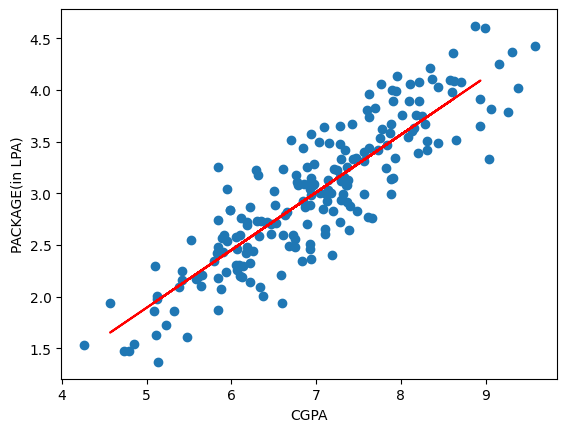

In [18]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_test,lr.predict(X_test),color='red')
plt.xlabel('CGPA')
plt.ylabel('PACKAGE(in LPA)')

In [21]:
m=lr.coef_
b=lr.intercept_q
#y=mx+b

np.float64(-0.8961119222429144)

In [26]:
lr.predict(X_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])